# Learning Curve Analysis: Experiment 2

**Objective**: Analyze how method performance degrades as the number of training rows decreases.

---

## Overview

**Experiment 2** evaluates performance degradation across varying training set sizes:
1. Tests methods at multiple row limits (e.g., 50k, 40k, ..., 1k rows)
2. Uses **NO HPO** (default parameters only) to isolate the effect of data size
3. Identifies which methods are most robust to limited training data
4. Helps select methods appropriate for small vs. large datasets

This notebook provides:
- **Learning Curve Plots**: Performance vs. training set size
- **Degradation Analysis**: How much performance drops as data decreases
- **Robustness Rankings**: Which methods maintain performance with less data
- **Heatmaps**: Performance matrices across row limits and methods

---

## 1. Setup & Configuration

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# =============================================================================
# SETUP PATHS (Notebook is in notebooks/ folder)
# =============================================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # notebooks/ -> project root
sys.path.insert(0, str(PROJECT_ROOT))

EXPERIMENT_NAME = "experiment2"
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT_NAME
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = RESULTS_DIR / "figures"

print("=" * 80)
print("  EXPERIMENT 2 POST-ANALYSIS: LEARNING CURVE ANALYSIS")
print("=" * 80)
print(f"Project root:       {PROJECT_ROOT}")
print(f"Results directory:  {RESULTS_DIR}")
print(f"Summary directory:  {SUMMARY_DIR}")
print(f"Figures directory:  {FIGURES_DIR}")

# =============================================================================
# GENERATE SUMMARIES IF NOT ALREADY PRESENT
# =============================================================================

# Check if summary folder exists and has files
if SUMMARY_DIR.exists() and any(SUMMARY_DIR.glob("*.csv")):
    print(f"\n Summary files already exist. Skipping generation.")
    print(f"   (Delete {SUMMARY_DIR} manually to regenerate)")
else:
    print(f"\n Summary files not found. Generating summaries...")
    
    # Import and run summarize_results
    from src.utils.summarize_results import summarize_results
    
    print("\n" + "=" * 80)
    summarize_results(experiment=EXPERIMENT_NAME)
    print("=" * 80)

# Ensure figures directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("\n Setup complete! Ready for analysis.")
print("=" * 80)

  EXPERIMENT 2 POST-ANALYSIS: LEARNING CURVE ANALYSIS
Project root:       c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Results directory:  c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2
Summary directory:  c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2\summary
Figures directory:  c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2\figures

 Summary files not found. Generating summaries...

  SUMMARIZING RESULTS: EXPERIMENT2 (LEARNING CURVE)

Experiment directory: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2
Summary output: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2\summary

--------------------------------------------------------------------------------
  PD RE

In [2]:
# Plotting configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')

# Color schemes
CMAP_PERFORMANCE = 'RdYlGn'       # Red (bad) to Green (good)
CMAP_DEGRADATION = 'RdYlGn_r'     # Green (low degradation) to Red (high)
CMAP_TIME = 'YlOrRd'              # Yellow (fast) to Red (slow)

# Use a distinct color palette for learning curves
N_COLORS = 20
LEARNING_CURVE_PALETTE = sns.color_palette('husl', n_colors=N_COLORS)

## 2. Data Loading

In [3]:
# Load raw and aggregated results
try:
    pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
    pd_agg = pd.read_csv(SUMMARY_DIR / "summary_pd_aggregated.csv")
    has_pd = True
except FileNotFoundError:
    print("Warning: PD results not found")
    pd_raw = pd.DataFrame()
    pd_agg = pd.DataFrame()
    has_pd = False

try:
    lgd_raw = pd.read_csv(SUMMARY_DIR / "summary_lgd_raw.csv")
    lgd_agg = pd.read_csv(SUMMARY_DIR / "summary_lgd_aggregated.csv")
    has_lgd = True
except FileNotFoundError:
    print("Warning: LGD results not found")
    lgd_raw = pd.DataFrame()
    lgd_agg = pd.DataFrame()
    has_lgd = False

print("\n Data Overview:")

if has_pd and not pd_raw.empty:
    row_limits_pd = sorted(pd_raw['row_limit'].unique(), reverse=True)
    print(f"\nPD (Probability of Default):")
    print(f"  - Raw results: {len(pd_raw)} fold results")
    print(f"  - Methods: {pd_raw['method'].nunique()}")
    print(f"  - Datasets: {pd_raw['dataset'].nunique()}")
    print(f"  - Row limits: {len(row_limits_pd)} ({max(row_limits_pd):,} -> {min(row_limits_pd):,})")
    print(f"  - Methods: {sorted(pd_raw['method'].unique())}")

if has_lgd and not lgd_raw.empty:
    row_limits_lgd = sorted(lgd_raw['row_limit'].unique(), reverse=True)
    print(f"\nLGD (Loss Given Default):")
    print(f"  - Raw results: {len(lgd_raw)} fold results")
    print(f"  - Methods: {lgd_raw['method'].nunique()}")
    print(f"  - Datasets: {lgd_raw['dataset'].nunique()}")
    print(f"  - Row limits: {len(row_limits_lgd)} ({max(row_limits_lgd):,} -> {min(row_limits_lgd):,})")
    print(f"  - Methods: {sorted(lgd_raw['method'].unique())}")


 Data Overview:

PD (Probability of Default):
  - Raw results: 47524 fold results
  - Methods: 10
  - Datasets: 10
  - Row limits: 147 (15,000 -> 500)
  - Methods: ['LogReg', 'catboost', 'ftt', 'lightgbm', 'mitra', 'tabicl', 'tabpfn', 'tabpfn_real', 'tabpfn_v2', 'xgboost']

LGD (Loss Given Default):
  - Raw results: 9480 fold results
  - Methods: 7
  - Datasets: 2
  - Row limits: 146 (15,000 -> 500)
  - Methods: ['LinearRegression', 'autoint', 'catboost', 'lightgbm', 'modernNCA', 'tabpfn_v2', 'xgboost']


In [4]:
# Display sample of raw data
if has_pd and not pd_raw.empty:
    print("\nSample PD Raw Data (first 10 rows):")
    display(pd_raw.head(10))
    
    print("\nPD Aggregated Data columns:")
    print(pd_agg.columns.tolist())


Sample PD Raw Data (first 10 rows):


,method,dataset,task,hpo_mode,fold_id,Optimal_Threshold,AUC,Gini,Avg_Precision,KS,...,F1,Precision,Recall,MCC,train_time,n_clipped_below,n_clipped_above,n_num_features,n_cat_features,row_limit
0,LogReg,0002.taiwan_creditcard,pd,NO_HPO,1,0.267374,0.748239,0.496477,0.513580,0.411572,...,0.534183,0.503603,0.568716,0.392619,0.014775,0.0,0.0,23,0,15000
1,LogReg,0002.taiwan_creditcard,pd,NO_HPO,2,0.257475,0.730751,0.461501,0.501365,0.388781,...,0.512479,0.474576,0.556962,0.361476,0.011999,0.0,0.0,23,0,15000
2,LogReg,0002.taiwan_creditcard,pd,NO_HPO,3,0.277273,0.734045,0.468090,0.497238,0.400536,...,0.526497,0.502881,0.552441,0.384509,0.015458,0.0,0.0,23,0,15000
3,xgboost,0002.taiwan_creditcard,pd,NO_HPO,1,0.247576,0.789346,0.578693,0.572497,0.458724,...,0.552632,0.511538,0.600904,0.414359,0.381481,0.0,0.0,23,0,15000
4,xgboost,0002.taiwan_creditcard,pd,NO_HPO,2,0.267374,0.764606,0.529213,0.540992,0.409886,...,0.525164,0.509194,0.542169,0.385026,0.083740,0.0,0.0,23,0,15000
5,xgboost,0002.taiwan_creditcard,pd,NO_HPO,3,0.267374,0.760081,0.520161,0.550354,0.392582,...,0.520588,0.508621,0.533133,0.380348,0.077469,0.0,0.0,23,0,15000
6,xgboost,0002.taiwan_creditcard,pd,NO_HPO,4,0.277273,0.748744,0.497487,0.511607,0.386567,...,0.509252,0.500000,0.518854,0.366809,0.081892,0.0,0.0,23,0,15000
7,xgboost,0002.taiwan_creditcard,pd,NO_HPO,5,0.306970,0.770190,0.540381,0.529924,0.436565,...,0.543705,0.580479,0.511312,0.425958,0.074795,0.0,0.0,23,0,15000
8,lightgbm,0002.taiwan_creditcard,pd,NO_HPO,1,0.049596,0.752628,0.505256,0.512124,0.402970,...,0.521236,0.455056,0.609940,0.365642,1.812815,0.0,0.0,23,0,15000
9,lightgbm,0002.taiwan_creditcard,pd,NO_HPO,2,0.039697,0.736701,0.473402,0.498999,0.363808,...,0.489375,0.427447,0.572289,0.322191,1.662261,0.0,0.0,23,0,15000



PD Aggregated Data columns:
['method', 'dataset', 'row_limit', 'task', 'n_folds', 'AUC_mean', 'AUC_std', 'AUC_min', 'AUC_max', 'Accuracy_mean', 'Accuracy_std', 'Accuracy_min', 'Accuracy_max', 'Avg_Precision_mean', 'Avg_Precision_std', 'Avg_Precision_min', 'Avg_Precision_max', 'Balanced_Accuracy_mean', 'Balanced_Accuracy_std', 'Balanced_Accuracy_min', 'Balanced_Accuracy_max', 'Brier_mean', 'Brier_std', 'Brier_min', 'Brier_max', 'F1_mean', 'F1_std', 'F1_min', 'F1_max', 'Gini_mean', 'Gini_std', 'Gini_min', 'Gini_max', 'KS_mean', 'KS_std', 'KS_min', 'KS_max', 'LogLoss_mean', 'LogLoss_std', 'LogLoss_min', 'LogLoss_max', 'MCC_mean', 'MCC_std', 'MCC_min', 'MCC_max', 'Precision_mean', 'Precision_std', 'Precision_min', 'Precision_max', 'Recall_mean', 'Recall_std', 'Recall_min', 'Recall_max', 'row_limit_mean', 'row_limit_std', 'row_limit_min', 'row_limit_max', 'train_time_mean', 'train_time_std', 'train_time_min', 'train_time_max', 'n_clipped_below_mean', 'n_clipped_below_std', 'n_clipped_below

## 3. Helper Functions

In [5]:
def plot_learning_curves(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    dataset: str = None,
    top_n: int = 15,
    figsize: tuple = (14, 8),
    show_std: bool = True
):
    """
    Plot learning curves showing performance vs. row limit.
    
    Args:
        df: Aggregated dataframe with row_limit column
        metric: Metric to plot (e.g., 'AUC', 'R2')
        task_name: 'PD' or 'LGD'
        dataset: Optional specific dataset to plot
        top_n: Number of top methods to show
        figsize: Figure size
        show_std: Whether to show standard deviation bands
    """
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'
    
    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None
    
    # Filter by dataset if specified
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df['dataset'] == dataset]
        title_suffix = f" - {dataset}"
    else:
        # Average across all datasets
        plot_df = plot_df.groupby(['method', 'row_limit']).agg({
            mean_col: 'mean',
            std_col: 'mean'
        }).reset_index()
        title_suffix = " (Averaged Across Datasets)"
    
    # Get top N methods by average performance at highest row limit
    max_row_limit = plot_df['row_limit'].max()
    top_methods = (
        plot_df[plot_df['row_limit'] == max_row_limit]
        .nlargest(top_n, mean_col)['method']
        .tolist()
    )
    
    # Filter to top methods
    plot_df = plot_df[plot_df['method'].isin(top_methods)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each method
    colors = sns.color_palette('husl', n_colors=len(top_methods))
    
    for i, method in enumerate(top_methods):
        method_df = plot_df[plot_df['method'] == method].sort_values('row_limit')
        
        x = method_df['row_limit'].values
        y = method_df[mean_col].values
        
        # Plot line
        ax.plot(x, y, 'o-', label=method, color=colors[i], linewidth=2, markersize=6)
        
        # Add std band if available and requested
        if show_std and std_col in method_df.columns:
            y_std = method_df[std_col].values
            ax.fill_between(x, y - y_std, y + y_std, color=colors[i], alpha=0.15)
    
    ax.set_xlabel('Number of Training Rows', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Learning Curves: {metric}{title_suffix}',
                 fontsize=14, fontweight='bold', pad=15)
    
    # Format x-axis with thousands separator
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # Legend outside plot
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save figure
    ds_suffix = f"_{dataset.replace('.', '_')}" if dataset else ""
    filename = FIGURES_DIR / f"{task_name.lower()}_learning_curve_{metric.lower()}{ds_suffix}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

In [6]:
def plot_learning_curve_heatmap(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    dataset: str = None,
    figsize: tuple = (18, 10)
):
    """
    Create a heatmap showing performance across methods and row limits.
    
    Args:
        df: Aggregated dataframe with row_limit column
        metric: Metric to visualize
        task_name: 'PD' or 'LGD'
        dataset: Optional specific dataset
        figsize: Figure size
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found")
        return None
    
    # Filter by dataset if specified
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df['dataset'] == dataset]
        title_suffix = f" - {dataset}"
    else:
        # Average across datasets
        plot_df = plot_df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
        title_suffix = " (Averaged)"
    
    # Create pivot table: methods (rows) x row_limits (columns)
    pivot = plot_df.pivot(index='method', columns='row_limit', values=mean_col)
    
    # Sort row limits (columns) in descending order
    pivot = pivot[sorted(pivot.columns, reverse=True)]
    
    # Sort methods by average performance
    pivot['_mean'] = pivot.mean(axis=1)
    pivot = pivot.sort_values('_mean', ascending=False)
    pivot = pivot.drop('_mean', axis=1)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Determine colormap based on metric
    if metric == 'R2':
        # R2 can be negative, center at 0
        vmax = max(abs(pivot.min().min()), abs(pivot.max().max()))
        sns.heatmap(
            pivot,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            center=0,
            vmin=-vmax,
            vmax=vmax,
            cbar_kws={'label': metric},
            linewidths=0.5,
            ax=ax
        )
    else:
        sns.heatmap(
            pivot,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            cbar_kws={'label': metric},
            linewidths=0.5,
            ax=ax
        )
    
    ax.set_title(f'{task_name} Performance Heatmap: {metric} vs Row Limit{title_suffix}',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Row Limit (Training Set Size)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Method', fontsize=12, fontweight='bold')
    
    # Format column labels with thousands separator
    ax.set_xticklabels([f'{int(x):,}' for x in pivot.columns], rotation=45, ha='right')
    
    plt.tight_layout()
    
    # Save figure
    ds_suffix = f"_{dataset.replace('.', '_')}" if dataset else ""
    filename = FIGURES_DIR / f"{task_name.lower()}_heatmap_rowlimit_{metric.lower()}{ds_suffix}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig, pivot

In [7]:
def calculate_degradation(
    df: pd.DataFrame,
    metric: str,
    task_name: str
) -> pd.DataFrame:
    """
    Calculate performance degradation as training data decreases.
    
    Metrics computed:
    - perf_max: Performance at maximum row limit
    - perf_min: Performance at minimum row limit
    - abs_drop: Absolute drop in performance
    - pct_drop: Percentage drop in performance
    - degradation_rate: Average drop per 1000 rows removed
    
    Args:
        df: Aggregated dataframe
        metric: Metric to analyze
        task_name: 'PD' or 'LGD'
    
    Returns:
        DataFrame with degradation metrics per method
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found")
        return pd.DataFrame()
    
    # Average across datasets first
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    
    results = []
    
    for method in avg_df['method'].unique():
        method_df = avg_df[avg_df['method'] == method].sort_values('row_limit')
        
        row_max = method_df['row_limit'].max()
        row_min = method_df['row_limit'].min()
        
        perf_max = method_df[method_df['row_limit'] == row_max][mean_col].values[0]
        perf_min = method_df[method_df['row_limit'] == row_min][mean_col].values[0]
        
        abs_drop = perf_max - perf_min
        pct_drop = (abs_drop / perf_max * 100) if perf_max != 0 else 0
        
        # Degradation rate: performance drop per 1000 rows removed
        rows_removed = row_max - row_min
        degradation_rate = (abs_drop / (rows_removed / 1000)) if rows_removed > 0 else 0
        
        results.append({
            'method': method,
            f'{metric}_at_max': perf_max,
            f'{metric}_at_min': perf_min,
            'row_max': row_max,
            'row_min': row_min,
            'abs_drop': abs_drop,
            'pct_drop': pct_drop,
            'degradation_rate_per_1k': degradation_rate
        })
    
    result_df = pd.DataFrame(results)
    
    # Sort by performance at max (best first)
    result_df = result_df.sort_values(f'{metric}_at_max', ascending=False)
    
    return result_df

In [8]:
def plot_degradation_analysis(
    degradation_df: pd.DataFrame,
    metric: str,
    task_name: str,
    figsize: tuple = (16, 6)
):
    """
    Create visualization of performance degradation.
    
    Shows:
    - Performance at max vs min row limit
    - Percentage drop
    """
    if degradation_df.empty:
        return None
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Sort by performance at max for consistent ordering
    df = degradation_df.sort_values(f'{metric}_at_max', ascending=False)
    methods = df['method'].values
    
    # Plot 1: Performance at max vs min
    ax1 = axes[0]
    x = np.arange(len(methods))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df[f'{metric}_at_max'], width, label=f'Max Rows ({int(df["row_max"].iloc[0]):,})', color='forestgreen', alpha=0.8)
    bars2 = ax1.bar(x + width/2, df[f'{metric}_at_min'], width, label=f'Min Rows ({int(df["row_min"].iloc[0]):,})', color='indianred', alpha=0.8)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, rotation=45, ha='right')
    ax1.set_ylabel(metric, fontweight='bold')
    ax1.set_title(f'{metric} at Max vs Min Row Limit', fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Percentage drop
    ax2 = axes[1]
    colors = ['forestgreen' if x < 5 else 'gold' if x < 15 else 'indianred' for x in df['pct_drop']]
    bars = ax2.bar(x, df['pct_drop'], color=colors, alpha=0.8, edgecolor='black')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, rotation=45, ha='right')
    ax2.set_ylabel('Performance Drop (%)', fontweight='bold')
    ax2.set_title('Percentage Drop (Max -> Min Rows)', fontweight='bold')
    ax2.axhline(y=5, color='green', linestyle='--', alpha=0.5, label='5% threshold')
    ax2.axhline(y=15, color='red', linestyle='--', alpha=0.5, label='15% threshold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(df['pct_drop']):
        ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
    
    # Plot 3: Degradation rate
    ax3 = axes[2]
    df_sorted = df.sort_values('degradation_rate_per_1k', ascending=True)
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(df_sorted)))
    
    ax3.barh(df_sorted['method'], df_sorted['degradation_rate_per_1k'], color=colors, alpha=0.8, edgecolor='black')
    ax3.set_xlabel(f'{metric} Drop per 1K Rows Removed', fontweight='bold')
    ax3.set_title('Degradation Rate (Lower = More Robust)', fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    plt.suptitle(f'{task_name} Performance Degradation Analysis', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    filename = FIGURES_DIR / f"{task_name.lower()}_degradation_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

In [9]:
def plot_robustness_ranking(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    figsize: tuple = (12, 8)
):
    """
    Create a scatter plot showing performance vs robustness.
    
    X-axis: Performance at max row limit (higher = better)
    Y-axis: Performance drop percentage (lower = more robust)
    
    Best methods are in the bottom-right quadrant.
    """
    degradation_df = calculate_degradation(df, metric, task_name)
    
    if degradation_df.empty:
        return None
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x = degradation_df[f'{metric}_at_max']
    y = degradation_df['pct_drop']
    methods = degradation_df['method']
    
    # Create scatter plot
    scatter = ax.scatter(x, y, s=100, c=range(len(methods)), cmap='viridis', alpha=0.7, edgecolors='black')
    
    # Add method labels
    for i, method in enumerate(methods):
        ax.annotate(method, (x.iloc[i], y.iloc[i]), 
                   xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # Add quadrant lines
    ax.axhline(y=y.median(), color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=x.median(), color='gray', linestyle='--', alpha=0.5)
    
    # Add quadrant labels
    ax.text(x.max(), y.min(), 'BEST\n(High Perf, Low Drop)', ha='right', va='bottom', 
            fontsize=10, color='green', fontweight='bold', alpha=0.7)
    ax.text(x.min(), y.max(), 'WORST\n(Low Perf, High Drop)', ha='left', va='top',
            fontsize=10, color='red', fontweight='bold', alpha=0.7)
    
    ax.set_xlabel(f'{metric} at Maximum Row Limit', fontsize=12, fontweight='bold')
    ax.set_ylabel('Performance Drop (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Robustness vs Performance',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    filename = FIGURES_DIR / f"{task_name.lower()}_robustness_scatter_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

In [10]:
def plot_relative_performance(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    figsize: tuple = (14, 8)
):
    """
    Plot relative performance (normalized to performance at max row limit).
    
    This shows how much each method's performance drops relative to its best.
    A value of 1.0 means no drop, 0.9 means 10% drop.
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        return None
    
    # Average across datasets
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    
    # Calculate relative performance for each method
    relative_data = []
    
    for method in avg_df['method'].unique():
        method_df = avg_df[avg_df['method'] == method].sort_values('row_limit', ascending=False)
        max_perf = method_df[mean_col].iloc[0]  # Performance at max row limit
        
        for _, row in method_df.iterrows():
            relative_perf = row[mean_col] / max_perf if max_perf != 0 else 0
            relative_data.append({
                'method': method,
                'row_limit': row['row_limit'],
                'relative_perf': relative_perf
            })
    
    rel_df = pd.DataFrame(relative_data)
    
    # Get top methods by performance at max
    max_row = avg_df['row_limit'].max()
    top_methods = (
        avg_df[avg_df['row_limit'] == max_row]
        .nlargest(12, mean_col)['method'].tolist()
    )
    
    rel_df = rel_df[rel_df['method'].isin(top_methods)]
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = sns.color_palette('husl', n_colors=len(top_methods))
    
    for i, method in enumerate(top_methods):
        method_df = rel_df[rel_df['method'] == method].sort_values('row_limit')
        ax.plot(method_df['row_limit'], method_df['relative_perf'], 
               'o-', label=method, color=colors[i], linewidth=2, markersize=6)
    
    ax.set_xlabel('Number of Training Rows', fontsize=12, fontweight='bold')
    ax.set_ylabel('Relative Performance (1.0 = Best)', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Relative Performance Decay',
                 fontsize=14, fontweight='bold', pad=15)
    
    # Add reference line at 0.9 (10% drop)
    ax.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='10% drop threshold')
    ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='5% drop threshold')
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.7, 1.02)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_relative_performance_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

In [11]:
def create_rank_evolution_heatmap(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    figsize: tuple = (16, 10)
):
    """
    Create a heatmap showing how method RANKS change across row limits.
    
    This reveals which methods maintain their relative position vs which
    become better or worse as data size changes.
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        return None
    
    # Average across datasets
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    
    # Create pivot table
    pivot = avg_df.pivot(index='method', columns='row_limit', values=mean_col)
    
    # Calculate ranks (1 = best)
    rank_pivot = pivot.rank(ascending=False, method='min')
    
    # Sort columns (row limits) descending
    rank_pivot = rank_pivot[sorted(rank_pivot.columns, reverse=True)]
    
    # Sort methods by rank at max row limit
    max_col = rank_pivot.columns[0]
    rank_pivot = rank_pivot.sort_values(max_col)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.heatmap(
        rank_pivot,
        annot=True,
        fmt='.0f',
        cmap='RdYlGn_r',  # Reversed: green=rank 1, red=high rank
        cbar_kws={'label': 'Rank (1=Best)'},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(f'{task_name} Rank Evolution: {metric} Across Row Limits',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Row Limit', fontsize=12, fontweight='bold')
    ax.set_ylabel('Method', fontsize=12, fontweight='bold')
    
    # Format x-axis labels
    ax.set_xticklabels([f'{int(x):,}' for x in rank_pivot.columns], rotation=45, ha='right')
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_rank_evolution_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig, rank_pivot

---

# Part A: PD (Probability of Default) Analysis

---

## A1. Learning Curve Visualizations

### A1.1 Overall Learning Curves (AUC)

Creating PD AUC Learning Curves (Top 15 Methods)...
Saved: pd_learning_curve_auc.png


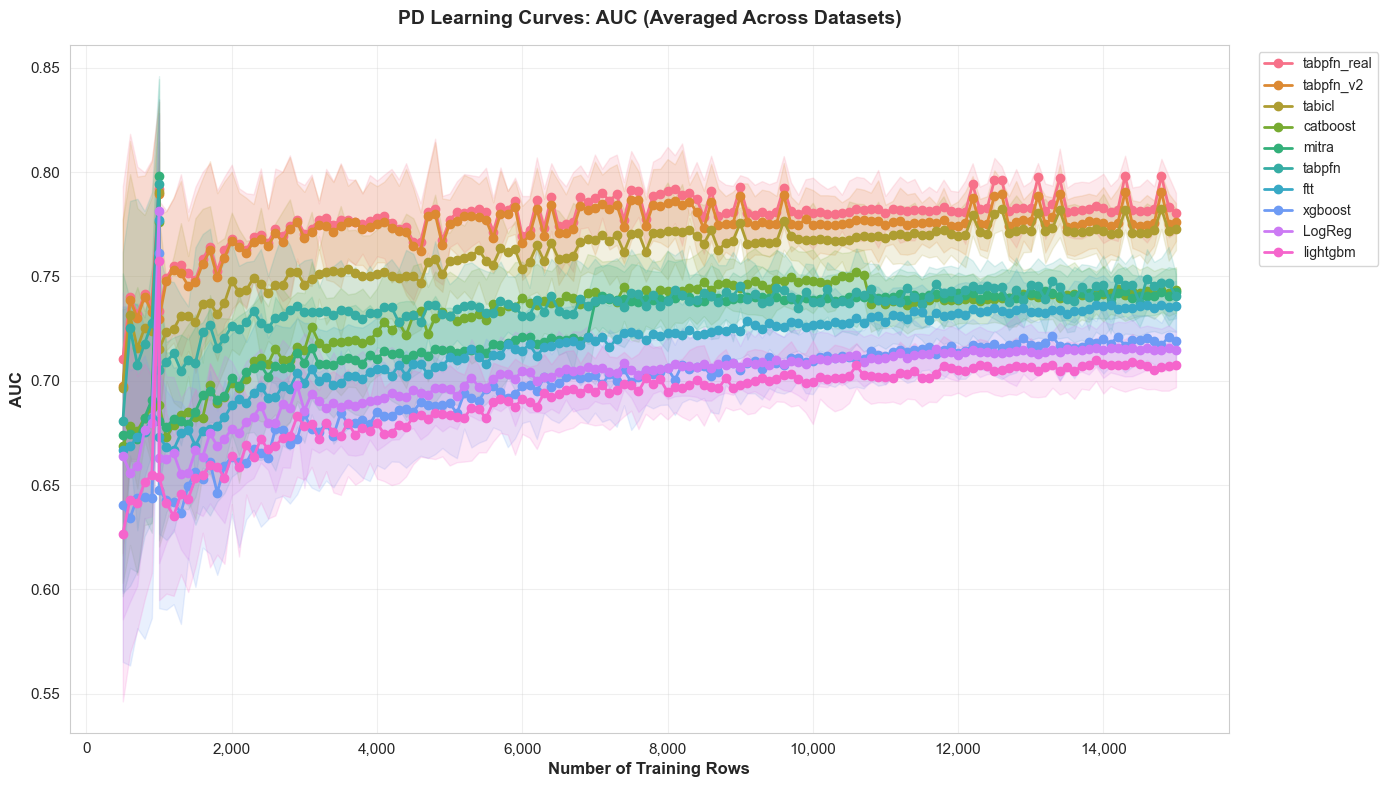

In [12]:
if has_pd and not pd_agg.empty:
    print("Creating PD AUC Learning Curves (Top 15 Methods)...")
    plot_learning_curves(pd_agg, 'AUC', 'PD', top_n=15)
    plt.show()
else:
    print("No PD data available")

### A1.2 Overall Learning Curves (F1)

Creating PD F1 Learning Curves (Top 15 Methods)...
Saved: pd_learning_curve_f1.png


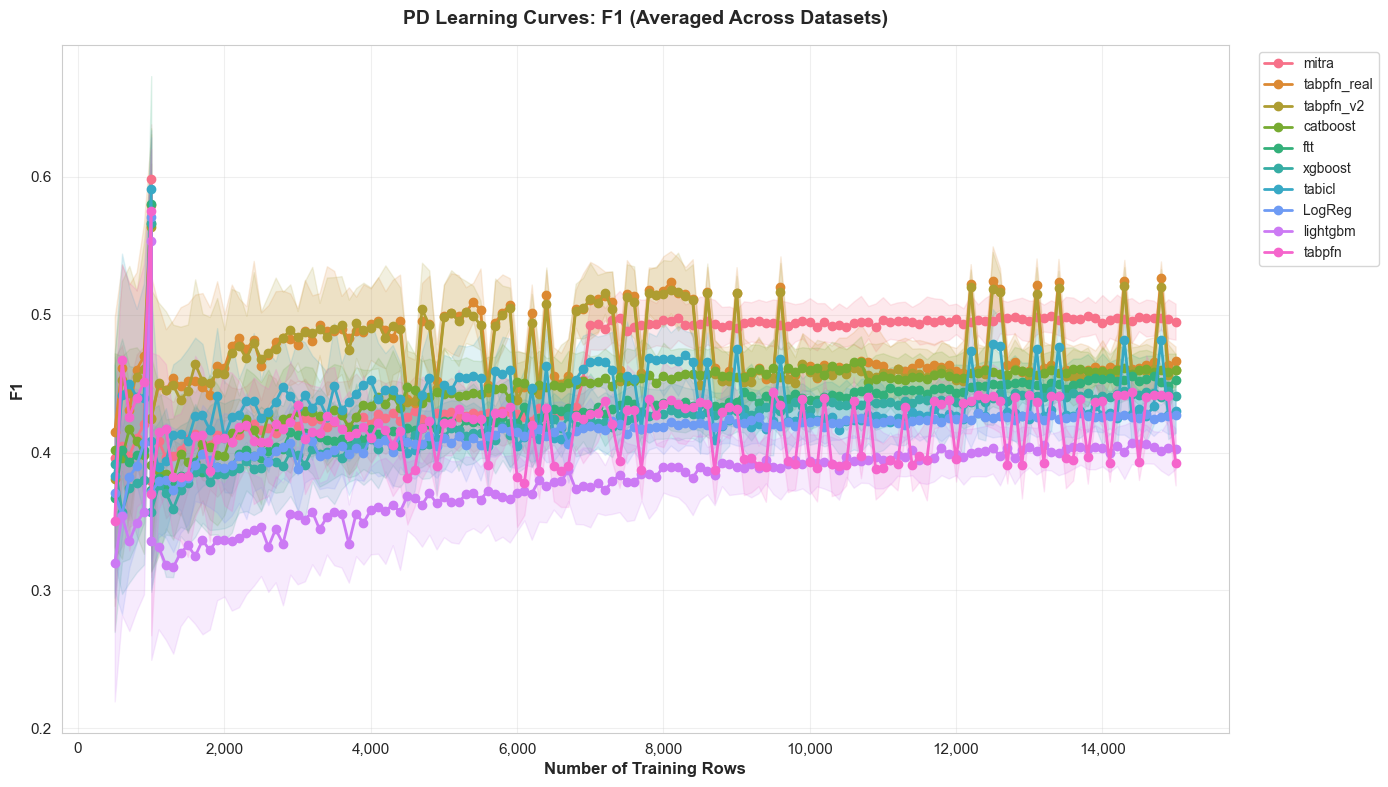

In [13]:
if has_pd and not pd_agg.empty:
    print("Creating PD F1 Learning Curves (Top 15 Methods)...")
    plot_learning_curves(pd_agg, 'F1', 'PD', top_n=15)
    plt.show()

### A1.3 Relative Performance Decay

Creating PD Relative Performance Decay...
Saved: pd_relative_performance_auc.png


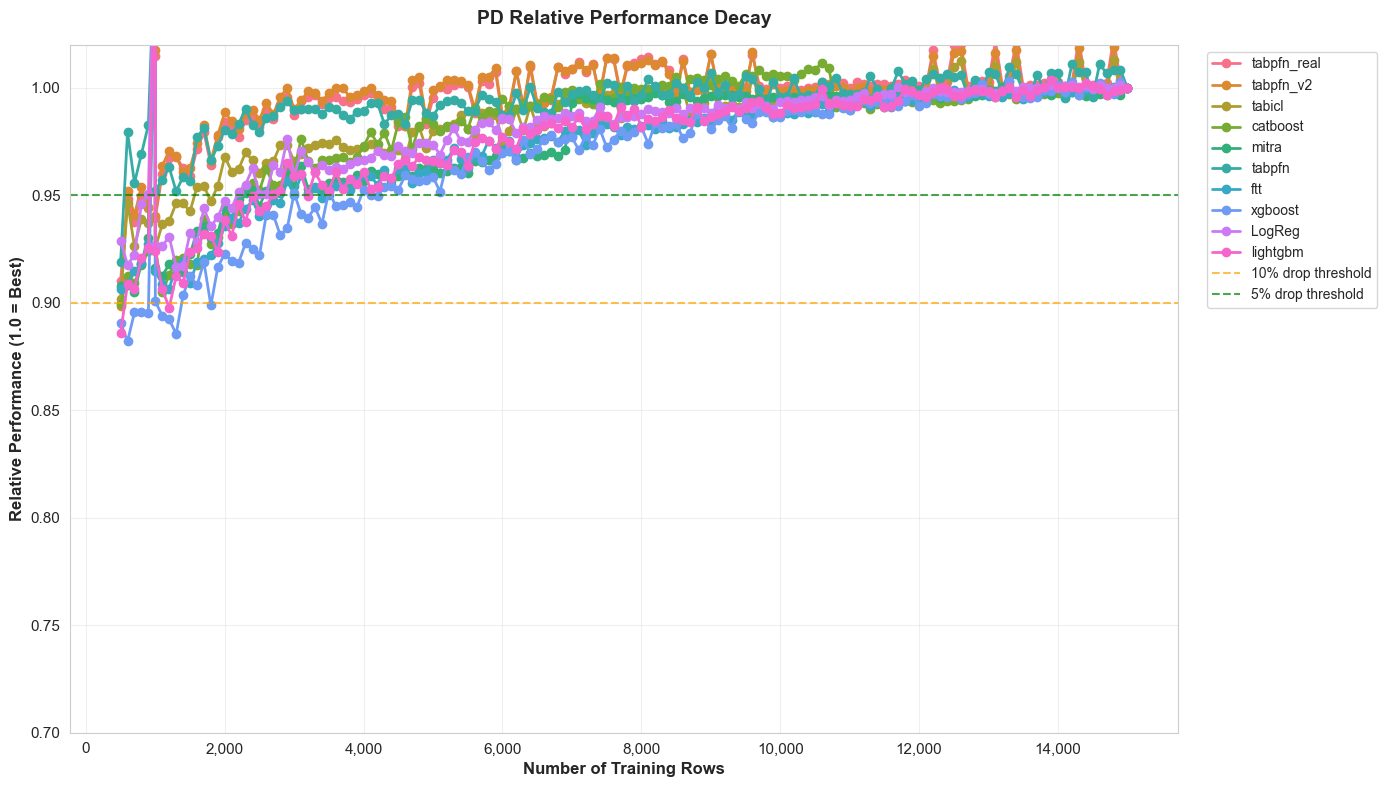

In [14]:
if has_pd and not pd_agg.empty:
    print("Creating PD Relative Performance Decay...")
    plot_relative_performance(pd_agg, 'AUC', 'PD')
    plt.show()

## A2. Performance Heatmaps

### A2.1 Performance Heatmap (Methods x Row Limits)

Creating PD AUC Performance Heatmap...


ValueError: The number of FixedLocator locations (49), usually from a call to set_ticks, does not match the number of labels (147).

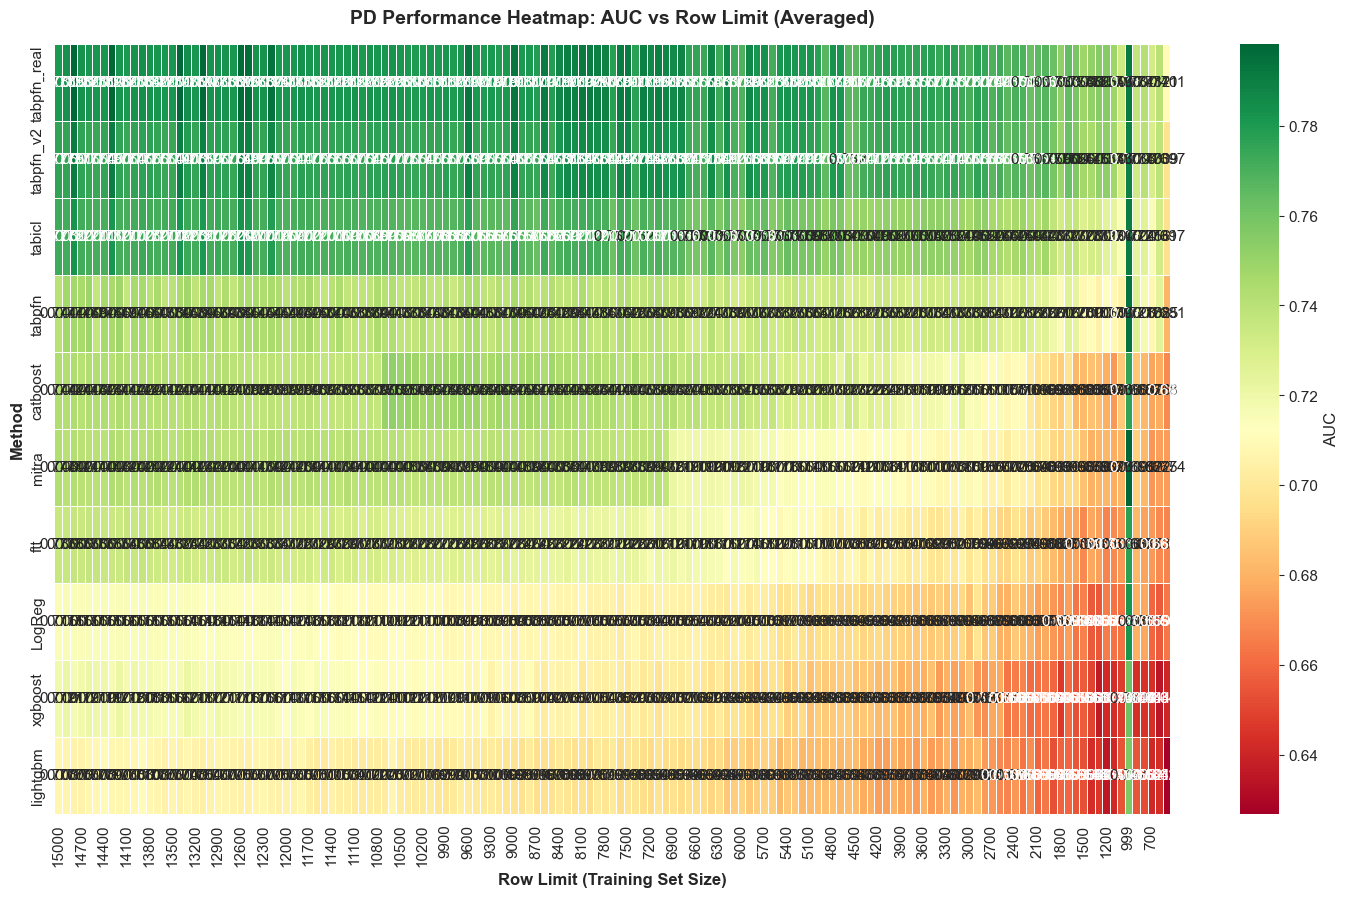

In [15]:
if has_pd and not pd_agg.empty:
    print("Creating PD AUC Performance Heatmap...")
    fig, pivot = plot_learning_curve_heatmap(pd_agg, 'AUC', 'PD')
    plt.show()

### A2.2 Rank Evolution Heatmap

In [ ]:
if has_pd and not pd_agg.empty:
    print("Creating PD Rank Evolution Heatmap...")
    fig, rank_pivot = create_rank_evolution_heatmap(pd_agg, 'AUC', 'PD')
    plt.show()
    
    print("\nMethods that improve rank as data decreases (potential small-data specialists):")
    max_col = rank_pivot.columns[0]
    min_col = rank_pivot.columns[-1]
    rank_change = rank_pivot[max_col] - rank_pivot[min_col]
    improvers = rank_change[rank_change > 2].sort_values(ascending=False)
    if not improvers.empty:
        print(improvers)
    else:
        print("No significant rank improvements found.")

## A3. Degradation Analysis

### A3.1 Degradation Metrics Table

In [ ]:
if has_pd and not pd_agg.empty:
    pd_degradation = calculate_degradation(pd_agg, 'AUC', 'PD')
    
    print("\n" + "=" * 80)
    print("  PD DEGRADATION ANALYSIS (AUC)")
    print("=" * 80)
    print("\nMethods sorted by performance at maximum row limit:")
    display(pd_degradation.round(4))
    
    print("\n" + "-" * 40)
    print("Most ROBUST methods (lowest % drop):")
    print("-" * 40)
    print(pd_degradation.nsmallest(5, 'pct_drop')[['method', 'AUC_at_max', 'AUC_at_min', 'pct_drop']].to_string(index=False))
    
    print("\n" + "-" * 40)
    print("LEAST robust methods (highest % drop):")
    print("-" * 40)
    print(pd_degradation.nlargest(5, 'pct_drop')[['method', 'AUC_at_max', 'AUC_at_min', 'pct_drop']].to_string(index=False))

### A3.2 Degradation Visualization

In [ ]:
if has_pd and not pd_agg.empty:
    print("Creating PD Degradation Analysis Plots...")
    plot_degradation_analysis(pd_degradation, 'AUC', 'PD')
    plt.show()

### A3.3 Robustness vs Performance Scatter

In [ ]:
if has_pd and not pd_agg.empty:
    print("Creating PD Robustness vs Performance Scatter...")
    plot_robustness_ranking(pd_agg, 'AUC', 'PD')
    plt.show()

## A4. Per-Dataset Analysis

In [ ]:
if has_pd and not pd_agg.empty:
    # Show learning curves for first 3 datasets
    datasets = sorted(pd_agg['dataset'].unique())[:3]
    
    for dataset in datasets:
        print(f"\nLearning Curve for Dataset: {dataset}")
        plot_learning_curves(pd_agg, 'AUC', 'PD', dataset=dataset, top_n=10)
        plt.show()

---

# Part B: LGD (Loss Given Default) Analysis

---

## B1. Learning Curve Visualizations

### B1.1 Overall Learning Curves (R2)

In [ ]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD R2 Learning Curves (Top 15 Methods)...")
    plot_learning_curves(lgd_agg, 'R2', 'LGD', top_n=15)
    plt.show()
else:
    print("No LGD data available")

### B1.2 Relative Performance Decay

In [ ]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD Relative Performance Decay...")
    plot_relative_performance(lgd_agg, 'R2', 'LGD')
    plt.show()

## B2. Performance Heatmaps

### B2.1 Performance Heatmap (Methods x Row Limits)

In [ ]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD R2 Performance Heatmap...")
    fig, pivot = plot_learning_curve_heatmap(lgd_agg, 'R2', 'LGD')
    plt.show()

### B2.2 Rank Evolution Heatmap

In [ ]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD Rank Evolution Heatmap...")
    fig, rank_pivot = create_rank_evolution_heatmap(lgd_agg, 'R2', 'LGD')
    plt.show()

## B3. Degradation Analysis

### B3.1 Degradation Metrics Table

In [ ]:
if has_lgd and not lgd_agg.empty:
    lgd_degradation = calculate_degradation(lgd_agg, 'R2', 'LGD')
    
    print("\n" + "=" * 80)
    print("  LGD DEGRADATION ANALYSIS (R2)")
    print("=" * 80)
    print("\nMethods sorted by performance at maximum row limit:")
    display(lgd_degradation.round(4))
    
    print("\n" + "-" * 40)
    print("Most ROBUST methods (lowest % drop):")
    print("-" * 40)
    print(lgd_degradation.nsmallest(5, 'pct_drop')[['method', 'R2_at_max', 'R2_at_min', 'pct_drop']].to_string(index=False))
    
    print("\n" + "-" * 40)
    print("LEAST robust methods (highest % drop):")
    print("-" * 40)
    print(lgd_degradation.nlargest(5, 'pct_drop')[['method', 'R2_at_max', 'R2_at_min', 'pct_drop']].to_string(index=False))

### B3.2 Degradation Visualization

In [ ]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD Degradation Analysis Plots...")
    plot_degradation_analysis(lgd_degradation, 'R2', 'LGD')
    plt.show()

### B3.3 Robustness vs Performance Scatter

In [ ]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD Robustness vs Performance Scatter...")
    plot_robustness_ranking(lgd_agg, 'R2', 'LGD')
    plt.show()

---

# Part C: Summary and Recommendations

---

## C1. Method Recommendations by Data Size

In [ ]:
def create_recommendations_table(df, metric, task_name):
    """
    Create a recommendations table showing best methods at different data sizes.
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        return None
    
    # Average across datasets
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    
    # Get unique row limits
    row_limits = sorted(avg_df['row_limit'].unique(), reverse=True)
    
    recommendations = []
    
    for row_limit in row_limits:
        subset = avg_df[avg_df['row_limit'] == row_limit].nlargest(5, mean_col)
        rec = {
            'Row Limit': f"{row_limit:,}",
            '1st': f"{subset.iloc[0]['method']} ({subset.iloc[0][mean_col]:.4f})",
            '2nd': f"{subset.iloc[1]['method']} ({subset.iloc[1][mean_col]:.4f})" if len(subset) > 1 else '-',
            '3rd': f"{subset.iloc[2]['method']} ({subset.iloc[2][mean_col]:.4f})" if len(subset) > 2 else '-',
        }
        recommendations.append(rec)
    
    rec_df = pd.DataFrame(recommendations)
    
    print(f"\n{'='*80}")
    print(f"  {task_name} TOP METHODS BY DATA SIZE ({metric})")
    print(f"{'='*80}")
    display(rec_df)
    
    return rec_df

if has_pd and not pd_agg.empty:
    pd_recommendations = create_recommendations_table(pd_agg, 'AUC', 'PD')

if has_lgd and not lgd_agg.empty:
    lgd_recommendations = create_recommendations_table(lgd_agg, 'R2', 'LGD')

## C2. Final Summary Statistics

In [ ]:
print("\n" + "=" * 80)
print("  EXPERIMENT 2: LEARNING CURVE ANALYSIS SUMMARY")
print("=" * 80)

if has_pd and not pd_agg.empty:
    print(f"\nPD Task:")
    print(f"  - Methods analyzed: {pd_agg['method'].nunique()}")
    print(f"  - Datasets: {pd_agg['dataset'].nunique()}")
    print(f"  - Row limit range: {pd_agg['row_limit'].max():,} -> {pd_agg['row_limit'].min():,}")
    print(f"  - Number of row limit steps: {pd_agg['row_limit'].nunique()}")

if has_lgd and not lgd_agg.empty:
    print(f"\nLGD Task:")
    print(f"  - Methods analyzed: {lgd_agg['method'].nunique()}")
    print(f"  - Datasets: {lgd_agg['dataset'].nunique()}")
    print(f"  - Row limit range: {lgd_agg['row_limit'].max():,} -> {lgd_agg['row_limit'].min():,}")
    print(f"  - Number of row limit steps: {lgd_agg['row_limit'].nunique()}")

print(f"\nFigures saved to: {FIGURES_DIR}")
print("=" * 80)

## C3. Key Insights

**Interpretation Guide:**

1. **Learning Curves** show how each method's performance changes with training data size.
   - Flat curves = robust to data size
   - Steep curves = data-hungry methods

2. **Degradation Analysis** quantifies the performance drop:
   - `pct_drop` < 5%: Very robust
   - `pct_drop` 5-15%: Moderately robust
   - `pct_drop` > 15%: Data-sensitive

3. **Robustness vs Performance Scatter**:
   - Bottom-right quadrant: Best overall (high performance, low degradation)
   - Top-right: Good performance but sensitive to data size
   - Bottom-left: Robust but lower performance

4. **Rank Evolution** shows competitive dynamics:
   - Methods that improve rank with less data are "small-data specialists"
   - Methods that drop rank need more data to shine

**For Method Selection:**
- Small datasets (< 5k rows): Prioritize robust methods
- Large datasets (> 20k rows): Can use data-hungry methods for potentially better performance